``AAPredPlot().group_cluster(X, kind=...)`` is the **sample-relation** counterpart of ``predict_group``: it takes the sample x feature matrix ``X`` (feature values from ``SequenceFeature.feature_matrix``, or SHAP values from a fitted ``ShapModel``) and clusters the samples by how they relate, overlaying prediction / metadata as **annotation tracks**.

- ``kind='clustermap'`` — hierarchically clustered sample x sample correlation heatmap, with one or two colored sidebars (``tracks``).

Each track is a dict: ``values`` (per-sample labels), optional ``colors``, ``title`` and ``where`` (``'top'``/``'left'``/``'both'``). A single track annotates both sidebars; two tracks give a distinct top and left annotation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False
aa.plot_settings()
aapred_plot = aa.AAPredPlot()

# Synthetic per-sample importance matrix: two blocks of samples with opposite signals.
rng = np.random.RandomState(0)
X = np.vstack([rng.normal(0.6, 0.2, size=(6, 20)), rng.normal(-0.6, 0.2, size=(6, 20))])
names = [f"Protein{i}" for i in range(12)]
group = ["Substrate"] * 6 + ["Non-substrate"] * 6
confidence = ["High", "High", "Mid", "Mid", "Low", "Low"] * 2

**Single annotation track.** One track colors both sidebars (the samples x samples matrix is symmetric). Here we also set ``names``, the ``cmap``, the colorbar label (``cbar_label``), the ``figsize`` and a ``title``:

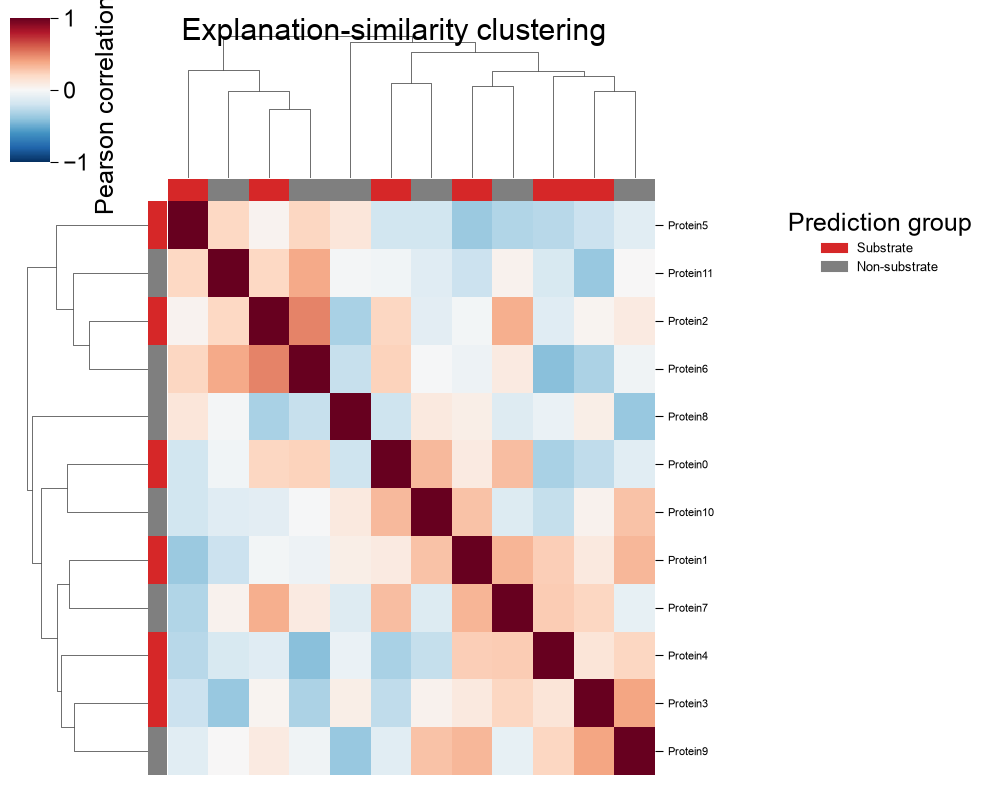

In [2]:
aapred_plot.group_cluster(X=X, kind="clustermap",
                          tracks=[dict(values=group, title="Prediction group",
                                       colors={"Substrate": "tab:red", "Non-substrate": "tab:gray"})],
                          names=names, cmap="RdBu_r", cbar_label="Pearson correlation (r)",
                          figsize=(8, 8), title="Explanation-similarity clustering")
plt.show()

**Two annotation tracks.** A second track adds a distinct sidebar — the first goes on top (columns), the second on the left (rows), each with its own colors and legend title:

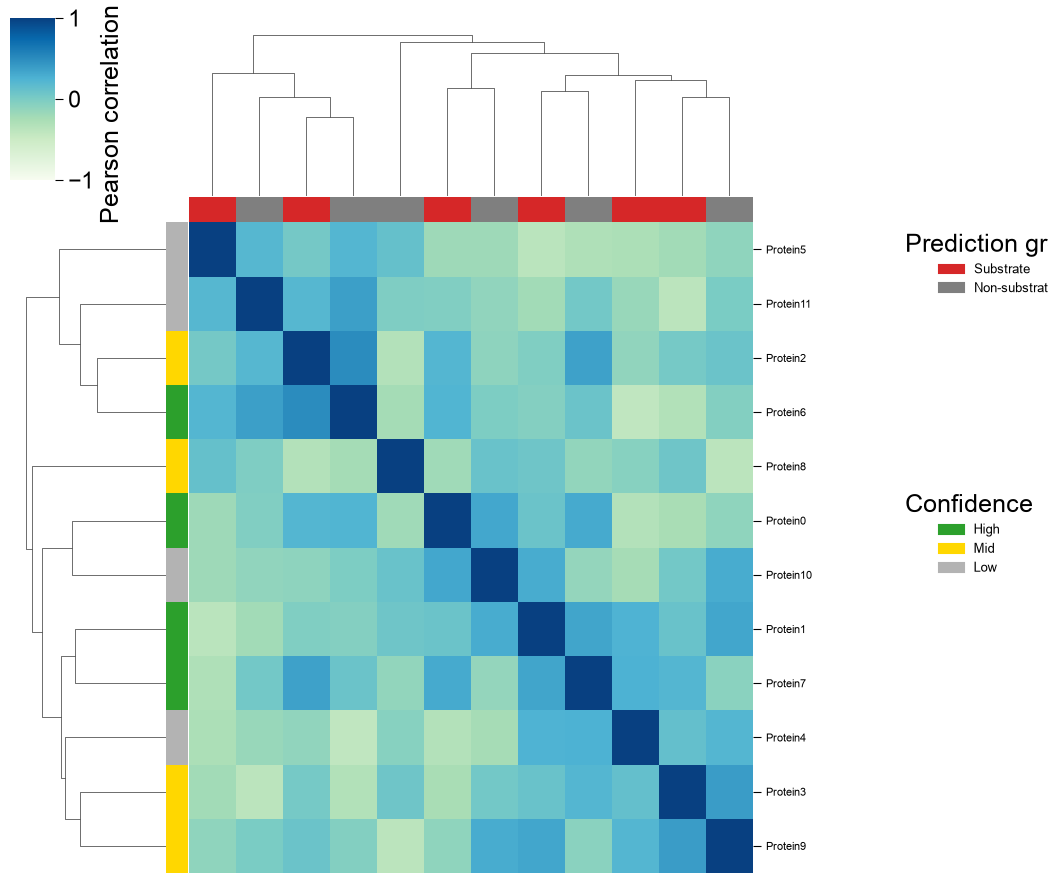

In [3]:
aapred_plot.group_cluster(X=X, kind="clustermap", names=names,
                          tracks=[dict(values=group, title="Prediction group", where="top",
                                       colors={"Substrate": "tab:red", "Non-substrate": "tab:gray"}),
                                  dict(values=confidence, title="Confidence", where="left",
                                       colors={"High": "tab:green", "Mid": "gold", "Low": "0.7"})])
plt.show()